# SciKit Demo Part 2

Today we will continue practicing with the Scikit learn library with a focus on more methods for evaluation and checking our model performance.

The dataset for today was obtained from Kaggle: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/data

The authors of this dataset explain that these features are anonymized using PCA* for privacy, so we won’t be interpreting them. Instead, we’re focusing on evaluation metrics today.

\* PCA (Principal Component Analysis) is an unsupervised technique (as compared to supervised methods, which we have been working with) that transforms data into new features ("principal components") that capture the most important patterns (as determined by the unsupervised model) while reducing dimensionality (number of features/columns). It’s often used to simplify data or anonymize features while preserving as much variation as possible.

In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

<font color="red">TODO (3 min)</font>  
Download the dataset off Canvas and load it in. You may need to change the location below to match where you saved your dataset.

In [3]:
# Load in our dataset
df = pd.read_csv("datasets/creditcard.csv")

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Step 1 - A Quick Refresher

<font color="red">TODO (10 min)</font>
Work with your group:
1. Split the data into training and testing sets (use an 80-20 split. 20% test subset)
2. Train a **Decision Tree Classifier** (using all the default parameters for today)
3. Evaluate your model using accuracy

*Note: Our target `y` (what we are trying to predict) is the `Class` column. Use everything else for the `X` features.* 

In [5]:
df.columns
X = df.drop("Class", axis=1)
y = df["Class"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train, y_train)
y_pred = dtc.predict(X_test)

In [8]:
eval_score = accuracy_score(y_test, y_pred)
print("Accuracy: " + str(eval_score))

Accuracy: 0.9990519995786665


## Step 2 - Take a Step Back (Data Understanding)

<font color="red">TODO (10 min)</font>
Once you are complete with the above, reflect and discuss with your groups:
1. What accuracy did you get?
2. Does this seem like a "good" model?
3. Would you trust it? Why or why not?

Before we decide.. we completely skipped our data understanding step!
Take a step back and explore the dataset further to help you answer the questions above. Think about:

- What do you notice about the data?
- Is there anything that might explain the model's performance?

Use any Pandas, seaborn, or matplotlib functions you think are helpful.

<font color="red">**DOUBLE CLICK TO TYPE IN YOUR RESPONSE**</font>

1. Accuracy: 0.9991
2. This may seem like a good model if only basing off the accuracy.
3. I wouldn't trust this model because we are only evaluating it on accuracy. We need to see other metrics to get a better understanding of the model's performace.

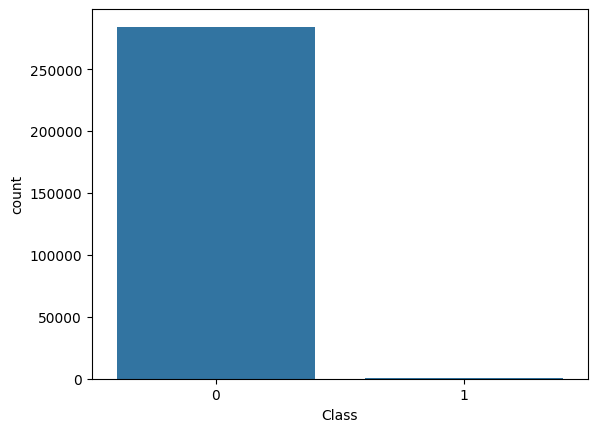

In [31]:
sns.barplot(x=df["Class"].value_counts().index, y=df["Class"].value_counts())
plt.show()

In [23]:
df["Class"].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

1. The dataset seems imbalanced for the target variable
2. The model's high accuracy is explained by the fact that the model is predicting the majority class (non-fraud) correctly, but it may be missing the minority class (fraud) which is more important to identify in this case.

## Step 3 - More Methods for Evaluation!  
### The Confusion Matrix

Accuracy tells us how often we are correct overall, but it doesn’t tell us *what kinds of mistakes* our model is making. A confusion matrix breaks predictions into four categories: true negatives (in our case, correctly predicting not fraud), false positives (flagging normal transactions as fraud), false negatives (missing fraud), and true positives (correctly detecting fraud). This helps us understand how well the model is actually performing on what we care about.

<font color="red">TODO (5 min)</font>
We've given you the exact method to import! Now look into the documentation to create a confusion matrix based off of the model we already trained earlier.

BUT before you write your code, answer: which value do you expect to be the largest? Why? (We aren't looking for right answers here. Just form a hypothesis to start!)

<font color="red">**DOUBLE CLICK TO TYPE IN YOUR RESPONSE**</font>

I expect the TN to be the largest because the model is predicting the majority class (non-fraud) correctly; and the dataset is imbalanced with more non-fraud cases than fraud cases.

In [17]:
from sklearn.metrics import confusion_matrix

In [18]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[56830    34]
 [   20    78]]


For your reference, here is the format of the confusion matrix:

|                      | Predicted: Not Fraud (0) | Predicted: Fraud (1) |
|----------------------|--------------------------|----------------------|
| **Actual: Not Fraud (0)** | True Negative (TN)         | False Positive (FP)   |
| **Actual: Fraud (1)**     | False Negative (FN)        | True Positive (TP)    |

If you want to verify this, run the cell below and confirm that each value matches the correct position in the confusion matrix.

In [19]:
# True Negatives (TN)
print(((y_test == 0) & (y_pred == 0)).sum())

# False Positives (FP)
print(((y_test == 0) & (y_pred == 1)).sum())

# False Negatives (FN)
print(((y_test == 1) & (y_pred == 0)).sum())

# True Positives (TP)
print(((y_test == 1) & (y_pred == 1)).sum())

56830
34
20
78


<font color="red">TODO (5 min)</font>
Once you've created your confusion matrix, discuss with your groups and answer the questions:
1. What do the values in your confusion matrix represent?
2. How many fraud cases did your model correctly detect?
3. How many fraud cases did your model miss?
4. Which type of mistake is worse in this scenario? Why?
5. Would you trust this model in a real-world setting?

<font color="red">**DOUBLE CLICK TO TYPE IN YOUR RESPONSE**</font>

1. The values represent what the model predicted vs what was actually true.
2. The model predicted 78 True positives.
3. The model missed 20 False Negatives.
4. Having high false negatives is worse because you are missing fraud cases that have high conquences. Its better to get false positives than false negatives in this case.
5. If I wanted a bulletproof model, I would not trust this model because it is missing 20 fraud cases (20% of all fraud cases). However, if I wanted a quick and simple model, I might trust this model as a starting point and then work on improving it to catch more fraud cases.

### Precision, Recall, and F1 Score  
Now that we understand the types of mistakes our model makes, we can measure them more directly.

- **Precision** tells us: out of all transactions we predicted as fraud, how many were actually fraud?
- **Recall** tells us: out of all actual fraud cases, how many did we catch?
- **F1 Score** balances both precision and recall.

These help us evaluate performance based on what we care about. For example, catching fraud vs avoiding false alarms.

<font color="red">TODO (5 min)</font>
Again, we've given you the exact method to import! Now look into the documentation to find the (1) precision, (2) recall, and (3) f1 score for our model.

In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [21]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [22]:
print("Precision: " + str(precision_score(y_test, y_pred)))
print("Recall: " + str(recall_score(y_test, y_pred)))
print("F1 Score: " + str(f1_score(y_test, y_pred)))

Precision: 0.6964285714285714
Recall: 0.7959183673469388
F1 Score: 0.7428571428571429


Here are the math equations for you to know exactly how each of these are being calculated!

- **Precision** = $\frac{TP}{TP + FP}$  
- **Recall** = $\frac{TP}{TP + FN}$  
- **F1 Score** = $2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$

<font color="red">TODO (5 min)</font>
Discuss and answer with your groups (and in markdown):

1. What does your recall score tell you about fraud detection?
2. What does your precision score tell you about false alarms?
3. Which metric do you think is more important in this problem? Why?
4. How does this compare to using accuracy alone?

<font color="red">**DOUBLE CLICK TO TYPE IN YOUR RESPONSE**</font>

1. Recall score is saying that about 79% of all actual fraud cases were correctly detected by the model.
2. Precision score is saying that about 68% of the predicted fraud cases were actually fraud.
3. Recall - We want to catch as many fraud cases as possible, even if we get false positives.
4. It gives a better understand of the model's performance on what we care about (catching fraud) rather than just overall correctness. 

### Cross Validation

So far, we evaluated our model using a single train/test split.
But what if we got lucky (or unlucky) with that split?

Cross-validation helps us get a more reliable estimate of model performance by splitting the data multiple times and averaging the results. This helps us understand how well the model generalizes to new, unseen data.

<font color="red">TODO (5 min)</font>
We've given you the exact method to import! Now look into the documentation to perform your cross validation. We want to use 5 splits and then find:
1. the recall for each of those splits
2. the average recall

In [32]:
from sklearn.model_selection import cross_val_score

In [ ]:
cvs_recall = cross_val_score(dtc, X, y, cv=5, scoring="recall")
print(f"Cross-validated recall scores: {cvs_recall}")

Cross-validated recall scores: [0.91919192 0.71717172 0.69387755 0.71428571 0.65306122]


In [34]:
print(f"Average cross-validated recall score: {cvs_recall.mean()}")

Average cross-validated recall score: 0.7395176252319109


<font color="red">TODO (5 min) </font>
After completing the above, answer with your groups (and in markdown):  
1. How do the cross-validation scores compare to your earlier results?
2. Are the scores consistent across folds, or do they vary?
3. Why might the performance change depending on the data split?
4. Do you trust this evaluation more than a single train/test split? Why or why not?

1. The recall score decreased slightly compared to the base model
2. The scores do very highly across folds, ranging from 0.65 to .91
3. Because the data is imbalanced, some splits will better predict fraud cases because it will have more fraud cases in the training set
4. Yes, because the model is trained on a variaty of splits, giving it more regularized performance.

<font color="red">**DOUBLE CLICK TO TYPE IN YOUR RESPONSE**</font>

## Optional: Other Evaluation Metrics

We focused on confusion matrices, precision, recall, and cross-validation today.

If you’re curious or have extra time, here are some additional evaluation methods commonly used in machine learning:

- ROC Curve / AUC
- Log Loss
- ROC Curve

Also note that many of the ones covered today were for **classification** machine learning methods. If you are working with **regression**, there will be a different set of evaluation metrics to use, such as:

- MAE
- MSE
- RMSE

You can explore these further in the Scikit-learn documentation:
https://scikit-learn.org/stable/modules/model_evaluation.html

Another useful resource: https://www.geeksforgeeks.org/machine-learning/metrics-for-machine-learning-model/ 

## A preview for our next class...

Today, we learned about more evaluation metrics to check our model's performance. Next class, we will learn more about hyperparameter tuning! And then if there's time, we'll have a mini datathon to see which group can train the highest performing model. :)